In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the stock dataset
df = pd.read_csv('2) Stock Prices Data Set.csv')

# Display first 5 rows and column names
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 32.8 MB
None
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391


In [3]:
print(df.columns)

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='str')


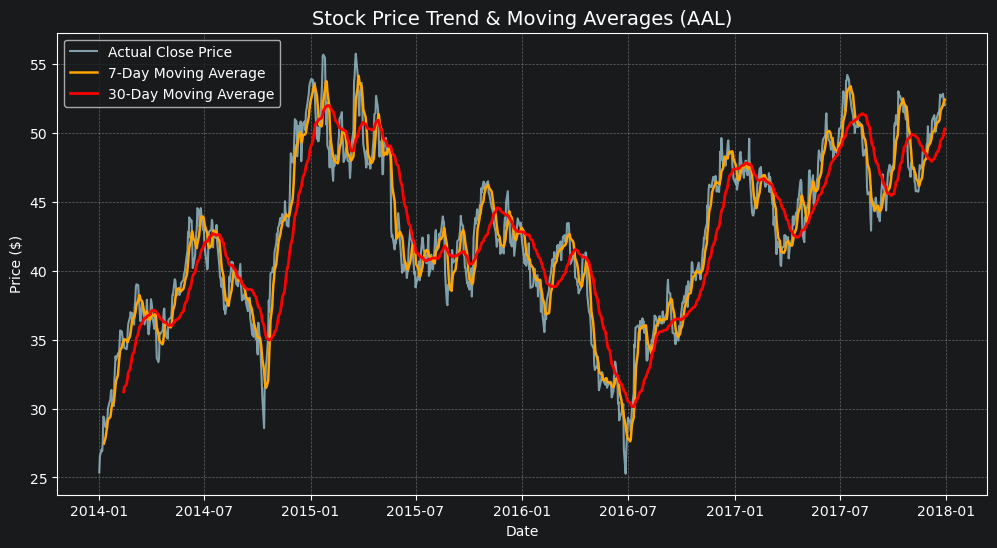

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load CSV fresh
df = pd.read_csv('2) Stock Prices Data Set.csv')

# 2. Clean column names
df.columns = df.columns.str.strip().str.lower()

# 3. Filter for ONE single stock symbol (e.g., the first symbol in the dataset)
target_symbol = df['symbol'].unique()[0]
df_single = df[df['symbol'] == target_symbol].copy()

# 4. Set date as index and sort
df_single['date'] = pd.to_datetime(df_single['date'])
df_single = df_single.sort_values('date').set_index('date')

# 5. Calculate Moving Averages on the single stock's 'close' price
df_single['MA_7'] = df_single['close'].rolling(window=7).mean()
df_single['MA_30'] = df_single['close'].rolling(window=30).mean()

# 6. Plot single stock trend
plt.figure(figsize=(12, 6))
plt.plot(
    df_single.index,
    df_single['close'],
    label='Actual Close Price',
    color='lightblue',
    alpha=0.7,
)
plt.plot(
    df_single.index,
    df_single['MA_7'],
    label='7-Day Moving Average',
    color='orange',
    linewidth=1.8,
)
plt.plot(
    df_single.index,
    df_single['MA_30'],
    label='30-Day Moving Average',
    color='red',
    linewidth=2,
)

plt.title(
    f'Stock Price Trend & Moving Averages ({target_symbol})', fontsize=14
)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("stock price trend.png")
plt.show()

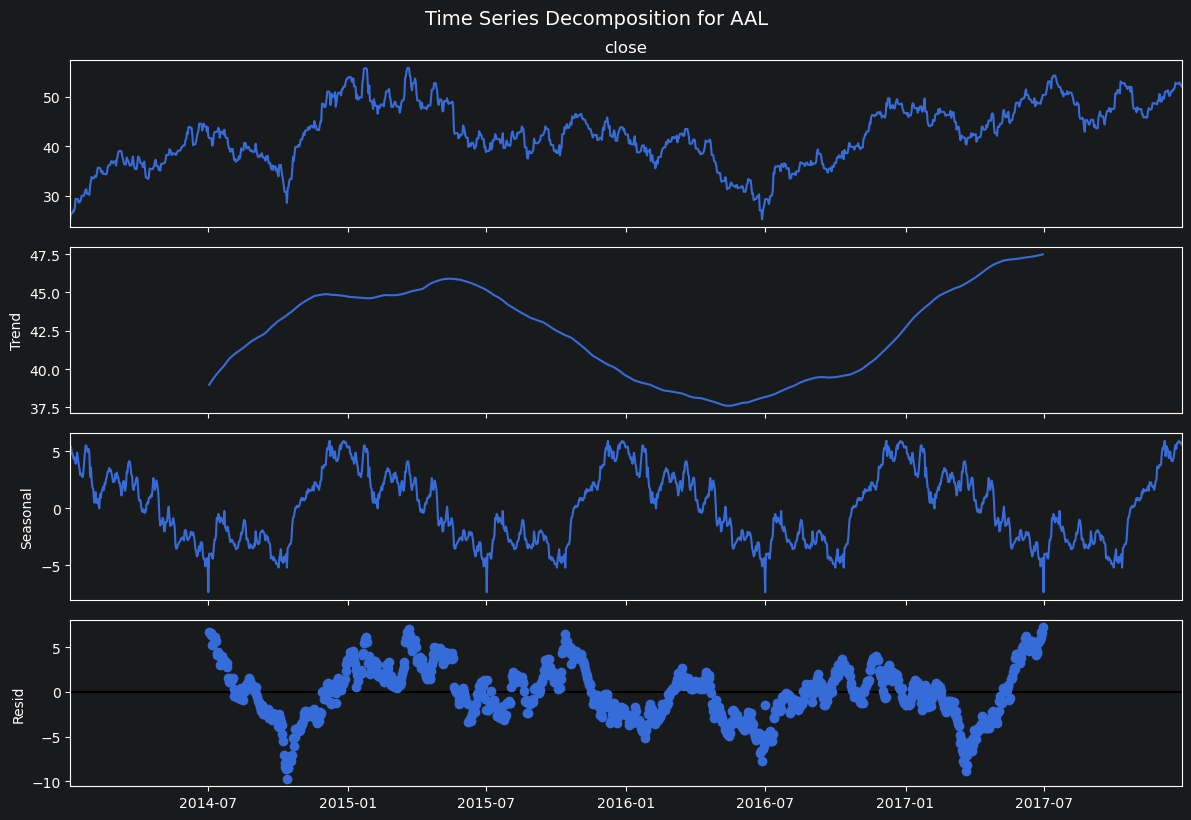

In [5]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Resample to daily frequency to handle any missing trading days/weekends
df_daily = df_single['close'].asfreq('D', method='ffill')

# 2. Decompose the series (period=365 for yearly seasonality, or period=30 for monthly)
result = seasonal_decompose(df_daily, model='additive', period=365)

# 3. Plot Trend, Seasonality, and Residuals
plt.rc('figure', figsize=(12, 8))
fig = result.plot()
plt.suptitle(
    f'Time Series Decomposition for {target_symbol}', fontsize=14, y=1.02
)
plt.savefig("time series decomposition.png")
plt.show()